In [6]:
pip install matplotlib ipympl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


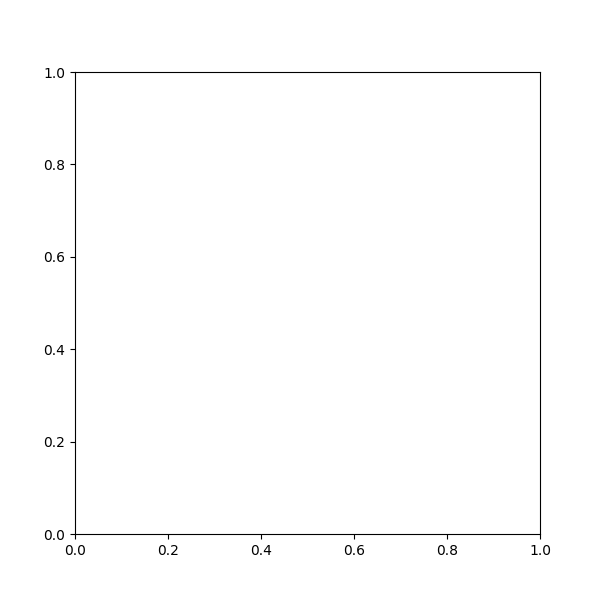

In [1]:
%matplotlib widget

import matplotlib.pyplot as plt
import matplotlib.animation as animation

# titik dari gambar
points = {
    "A": (2, 3), "B": (2, 4), "C": (3, 4), "D": (3, 3),
    "E": (2, -3), "F": (3, -3), "G": (2, -4), "H": (3, -4),
    "I": (2, 2), "J": (3, 2), "K": (2, 1), "L": (3, 1),
    "M": (2, -1), "N": (3, -1), "O": (2, -2), "P": (3, -2)
}

# kelompok kotak
boxes = [
    ["A", "B", "C", "D", "A"],
    ["E", "F", "H", "G", "E"],
    ["I", "J", "L", "K", "I"],
    ["M", "N", "P", "O", "M"]
]

fig, ax = plt.subplots(figsize=(6,6))

def update(frame):
    ax.clear()

    # transformasi mendekati sumbu x
    scale_y = 1 - frame / 100

    transformed = {}

    # ubah posisi titik
    for nama, (x, y) in points.items():
        y_baru = y * scale_y
        transformed[nama] = (x, y_baru)

    # gambar kotak
    for box in boxes:
        x_vals = []
        y_vals = []

        for titik in box:
            x, y = transformed[titik]
            x_vals.append(x)
            y_vals.append(y)

        ax.plot(x_vals, y_vals, color="blue", linewidth=2)

    # gambar titik + nama
    for nama, (x, y) in transformed.items():
        ax.scatter(x, y, color="red")
        ax.text(x + 0.05, y + 0.05, nama)

    # sumbu
    ax.axhline(0, color="black")
    ax.axvline(0, color="black")

    ax.set_xlim(0, 5)
    ax.set_ylim(-5, 5)

    ax.grid(True)
    ax.set_title("Transformasi Mendekati Sumbu X")

# simpan animasi ke variabel
ani = animation.FuncAnimation(
    fig,
    update,
    frames=101,
    interval=50,
    repeat=True
)

plt.show()